## __0. Giới thiệu__

### ĐỀ TÀI NHÓM: Phân loại cảm xúc văn bản tiếng Việt sử dụng mô hình PhoBERT v2 có hỗ trợ emoji (tên tiếng Anh: **Vietnamese Text Sentiment Analysis using PhoBERT v2 with Emoji Support**)

### Thành viên trong nhóm:
- Trần Khánh Duy (MSSV: 23110078)
- Lê Minh Huy (MSSV: 23110018)
- Lê Văn Quý (MSSV: 23110040)
- Đoàn Phú Quý (MSSV: 23110112)


### Mục tiêu và đóng góp của đề tài:

* Tích hợp Emoji vào từ điển như một token độc lập.
* Áp dụng kĩ thuật Copy Embedding Weights để chuyển ngữ nghĩa từ từ vựng tiếng Việt sang Emoji (Ví dụ: 😡 ← vector từ
”giận”).
* Kiểm chứng hiệu quả trên bộ dữ liệu UIT-VSMEC, so sánh trực tiếp với các baseline (SVM, CNN, BiLSTM) và PhoBert gốc.



## __1. Cơ sở lý thuyết__

### __Tổng quan mục đích của thư viện Transformers__






Kiến trúc Transformer là một mô hình học sâu (Deep Learning) mang tính cách mạng, được giới thiệu vào năm 2017 bởi Google trong bài báo "Attention Is All You Need". Đây là nền tảng của nhiều mô hình ngôn ngữ lớn (LLMs) hiện đại, bao gồm cả BERT, RoBERTa và PhoBERT đang dùng. __[Link tới bài báo này](https://arxiv.org/abs/1706.03762)__.

Transformer đã trở thành chuẩn mực trong NLP nhờ cơ chế Attention xử lý song song, vượt trội hơn RNN/LSTM về tốc độ và khả năng nắm bắt ngữ cảnh dài. Trong bài toán nhận diện cảm xúc, cơ chế self-attention giúp mô hình hiểu rõ sắc thái toàn cục (bao gồm phủ định, mỉa mai, emoji). Do mục tiêu là phân loại văn bản thay vì sinh chuỗi, đề tài sử dụng kiến trúc Transformer Encoder.


### __Vấn đề của các kiến trúc trước đó: Hiện tượng suy giảm gradient (Vanishing Gradient).__

Trong các mô hình như RNN cũ, khi cập nhật trọng số, mô hình phải sử dụng thuật toán lan truyền ngược (Backpropagation) qua từng bước thời gian (Time steps). Khi chuỗi dữ liệu đầu vào quá dài, đạo hàm bị nhân liên tiếp với các số nhỏ khiến gradient tiến về 0, gây ra hiện tượng "mất trí nhớ ngắn hạn".

Ví dụ: "Tôi sống ở Pháp ... [100 từ khác] ... nên tôi nói tiếng Pháp." Để điền đúng từ "Pháp" ở cuối, máy cần ngữ cảnh từ chữ "Pháp" ở đầu câu. Nếu bị Vanishing Gradient, thông tin từ đầu câu không thể truyền qua 100 bước để đến đích. Mạng chỉ dựa vào các từ gần nhất (ví dụ "nói tiếng") và có thể đoán sai là "Anh" hoặc "Việt".


Giải pháp của Transformer: Mô hình Transformer giải quyết triệt để vấn đề này bằng cách kết hợp hai cơ chế:

1.   Cơ chế Self-Attention (Tự chú ý - Quan trọng nhất): Thay vì xử lý tuần tự từng bước, nó cho phép từ cuối cùng nhìn thấy trực tiếp từ đầu tiên chỉ trong 1 bước tính toán (Kết nối song song). Khoảng cách giữa từ thứ 1 và từ thứ 100 bị xóa bỏ.
2.   Residual Connections (Add & Norm): Tạo các đường tắt (shortcut) giúp gradient có thể nhảy cóc qua các lớp xử lý sâu, đảm bảo tín hiệu huấn luyện không bị suy giảm khi mô hình có nhiều lớp (Deep Network)



### __Quy trình xử lý của Encoder__

Quy trình gồm 3 bước:

**Bước 1: Input Embedding**
* Đầu vào là **chuỗi văn bản đã được token hóa thành các token** (thường ở dạng subword). Mỗi token được ánh xạ sang một vector liên tục thông qua Input Embedding. Mục đích của bước này là **chuyển dữ liệu rời rạc** (token ID) sang không gian vector để mô hình có thể học và xử lý bằng các phép biến đổi tuyến tính/phi tuyến.

**Bước 2: Positional Encoding**
Transformer không có cơ chế đọc tuần tự theo thời gian như RNN/LSTM, do đó bản thân self-attention không thể suy ra thứ tự từ nếu chỉ dùng embedding. Vì vậy, mô hình cộng thêm Positional Encoding vào embedding để đưa thông tin vị trí vào biểu diễn đầu vào. Biểu diễn tại vị trí i sau bước này được mô tả khái quát:
$$
z_i = e(x_i) + p(i)
$$
*(Trong đó $e(x_i)$ là embedding và $p(i)$ là vector vị trí)*.

** Bước 3: Encoder Layer (Lặp lại N lần) Mỗi lớp bao gồm các thành phần con xử lý tuần tự:**

1.  **Multi-Head Self-Attention:** Mô-đun đầu tiên trong Encoder layer là Multi-Head Self-Attention. Tại đây, mỗi token có thể “chú ý” đến các token khác trong cùng chuỗi để tổng hợp thông tin ngữ cảnh. Cơ chế này giúp mô hình nắm bắt quan hệ phụ thuộc xa–gần, ví dụ các từ phủ định (“không”), từ chuyển ý (“nhưng”), hay các từ cảm xúc trong bài toán phân loại cảm xúc.
Cơ chế Multi-Head thực hiện attention nhiều lần song song với các không gian chiếu khác nhau, cho phép mô hình học nhiều kiểu quan hệ (cú pháp, ngữ nghĩa, nhấn mạnh cảm xúc…) cùng lúc. Kết quả được ghép (concatenate) và chiếu về kích thước chuẩn của mô hình.
2.  **Add & Norm (sau Attention):**
Sau Multi-Head Self-Attention là khối Add & Norm. Thành phần “Add” là residual connection, tức cộng đầu vào ban đầu của mô-đun attention vào đầu ra attention; sau đó “Norm” là Layer Normalization. Mục tiêu là:
* giữ lại thông tin gốc, giảm mất mát thông tin qua nhiều tầng,
* ổn định quá trình lan truyền gradient và giúp mô hình sâu học tốt hơn.

3.  **Feed Forward Network (FFN)**: Tiếp theo là Feed Forward Network (FFN). Đây là một mạng MLP nhỏ (thường gồm hai lớp tuyến tính và một hàm kích hoạt phi tuyến như GELU/ReLU) áp dụng độc lập cho từng vị trí token. FFN giúp mô hình tăng năng lực biểu diễn phi tuyến, xuất ra đặc trưng của từng token sau khi đã tổng hợp ngữ cảnh từ attention.
4.  **Add & Norm (sau FFN):** Sau FFN, mô hình tiếp tục áp dụng Add & Norm theo cùng nguyên tắc: residual connection + layer normalization. Đây là bước hoàn thiện một Encoder layer, đảm bảo tính ổn định khi lặp nhiều lớp và cải thiện khả năng hội tụ trong huấn luyện..

* Sau khi lặp N lần Encoder layer, ta thu được đầu ra của Encoder là một chuỗi biểu diễn ngữ cảnh cho toàn bộ câu.

Cụ thể:
* Mỗi token ban đầu chỉ là một vector “tĩnh” (embedding) mang nghĩa cơ bản của chính nó.
* Sau khi đi qua nhiều lớp self-attention và FFN, mỗi token sẽ trở thành một vector đã được “ngữ cảnh hoá”: nó không chỉ chứa nghĩa riêng của token đó, mà còn chứa thông tin về các token khác liên quan trong câu (phủ định “không”, chuyển ý “nhưng”, mức độ “rất”, từ cảm xúc, dấu câu, emoji,…).
Vì vậy, kết quả cuối cùng sau N lớp encoder là một tập các vector đại diện cho câu, trong đó:
* mỗi vector tương ứng một token
* nhưng mỗi token đã “hiểu” toàn bộ câu ở mức sâu hơn.


Liên hệ với phân loại cảm xúc: từ các biểu diễn ngữ cảnh này, mô hình sẽ chọn (hoặc tổng hợp) một biểu diễn đại diện cho toàn câu, sau đó đưa vào tầng phân loại (Fully Connected + Softmax) để dự đoán nhãn cảm xúc.



### __BERT__

Mô hình __BERT__ (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) là một mô hình máy học (**M**achine **L**earning - **ML**) mã nguồn mở được các nhà nghiên cứu tại Google phát triển để giải quyết nhiều bài toán xử lý ngôn ngữ tự nhiên (**N**atural **L**anguage **P**rocessing - **NLP**) và lần đầu được giới thiệu vào năm 2018 trong __[bài báo này](https://arxiv.org/abs/1810.04805)__.
> _Fun fact_: Dù không nhận ra nhưng thực ra ta tương tác với BERT hằng ngày đấy! Mỗi lần ta search trên Google thì chính mô hình này đã tham gia hỗ trợ trong việc hiểu bạn đang tìm kiếm gì để trả về kết quả tốt nhất. (__[source](https://searchengineland.com/google-bert-used-on-almost-every-english-query-342193)__)

Một số điểm đáng chú ý của mô hình này:
- BERT được huấn luyện trên Masked Language Model (MLM). Điều này có nghĩa là mô hình học bằng cách che lại một số từ trong câu và phải đoán từ đó bằng cách học hai chiều (Bidirectional) các từ còn lại của câu. Phương pháp này khá tương đồng với cách con người ta sử dụng ngôn ngữ.
> Trong quá trình học ngôn ngữ, không quan trọng ở quốc gia nào, học sinh cũng phải làm các bài tập điền vào chỗ trống để hoàn thành câu. Đây chính là ý tưởng đằng sau quá trình phát triển mô hình này. Bạn có thể điền vào chỗ trống từ còn thiếu trong câu sau không? <br>
> __"Em ... cơm chưa?"__ <br>
> Mô hình BERT, tương tự như cách bạn giải bài tập trên, cũng học bằng cách giải các bài tập như vậy. Trong quá trình training, xấp xỉ 15% số lượng từ trong câu sẽ bị ẩn đi và nhiệm vụ của BERT là đoán từ đó. Có lẽ trí tuệ nhân tạo và trí tuệ con người không thực sự khác biệt là bao.

- BERT cũng được huấn luyện trên Next Sentence Prediction (NSP). Điều đó giúp BERT học về mối quan hệ giữa các câu với nhau bằng cách dự đoán liệu một câu có phải là câu kế tiếp cho một câu khác. Công việc này được thực hiện song song với MLM nói trên với tỉ lệ xấp xỉ 1:1.
> Ví dụ: <br>
> __"Em ... cơm chưa?" - "Em ăn ... ạ."__ (đúng) <br>
> __"Em ... cơm chưa?" - "Chiều nay ai ra xứ ...."__ (sai)

- Về mặt bản chất, BERT thực chất chỉ là rất nhiều lớp Transformer Encoders đã được huấn luyện được nối với nhau. Mô hình Transformer hỗ trợ cho việc hiểu được mối quan hệ về mặt bối cảnh giữa các từ với nhau bằng cách đọc toàn bộ các chuỗi từ trong câu (ví dụ hiểu được _"cô ấy"_ là nhắc đến ai). Bằng cách sử dụng cơ chế tập trung (Attention), một thuật toán học sâu (Deep Learning) mạnh mẽ, mô hình có tính song song hóa (Parallelization) cao, sử dụng ít tài nguyên và dễ dàng học chuyển tiếp (Transfer Learning) để giải quyết các bài toán khác nhau.

### __RoBERTa: Tối ưu hoá công thức huấn luyện BERT__

__[Link dẫn tới bài báo RoBerta](https://arxiv.org/abs/1907.11692)__.

**RoBERTa** (Robustly Optimized BERT Pretraining Approach) là phiên bản tối ưu hóa của BERT. Điểm mấu chốt là RoBERTa **giữ nguyên kiến trúc Transformer Encoder** giống hệt BERT nhưng thay đổi hoàn toàn **quy trình tiền huấn luyện (pre-training recipe)** để khai thác hiệu quả hơn năng lực của mô hình.



### __So sánh BERT và RoBERTa (Những khác biệt cốt lõi)__

Sự khác biệt chính nằm ở chiến lược huấn luyện và cách xử lý dữ liệu:

**Mục tiêu huấn luyện (Training Objective)**
*  **BERT:** Sử dụng kết hợp **MLM** (Masked Language Modeling) và **NSP** (Next Sentence Prediction).
*  **RoBERTa:** Loại bỏ hoàn toàn **NSP**, chỉ tập trung tối đa vào **MLM**. Các nghiên cứu cho thấy việc loại bỏ NSP giúp đơn giản hóa và dồn năng lực mô hình vào việc học biểu diễn ngữ cảnh sâu hơn.

**Cải tiến quan trọng của RoBERTa (Dynamic Masking):**

*  **BERT (Static Masking):** Tạo mặt nạ (mask) cố định ngay từ giai đoạn chuẩn bị dữ liệu. Mỗi lần mô hình gặp lại một câu, nó chỉ học dự đoán đúng những vị trí đã bị che cố định đó.
*  **RoBERTa (Dynamic Masking):** Vị trí bị che sẽ **thay đổi ngẫu nhiên** mỗi lần mô hình gặp lại dữ liệu đó (qua các epoch khác nhau).

**Ví dụ minh họa Dynamic Masking:**
Giả sử có câu input: *"Phim này hay quá nhưng kết thúc hơi hụt hẫng."*

**Lần 1 (Epoch 1):** Che tính từ và danh từ cuối
*  **Input:** `Phim | này | [MASK] | quá | nhưng | [MASK] | hơi | hụt | hẫng | .`
*  **Labels:** `[MASK]1`="hay", `[MASK]2`="kết_thúc".

**Lần 2 (Epoch 2):** Che liên từ và trạng từ
*  **Input:** `Phim | này | hay | quá | [MASK] | kết_thúc | hơi | [MASK] | hẫng | .`
*  **Labels:** `[MASK]1`="nhưng", `[MASK]2`="hụt".

**Lần 3 (Epoch 3):** Che các vị trí khác
*  **Input:** `Phim | này | hay | [MASK] | nhưng | kết_thúc | [MASK] | hụt | hẫng | .`
*  **Labels:** `[MASK]1`="quá", `[MASK]2`="hơi".

$\Rightarrow$ **Lợi ích:** Dynamic masking biến một câu dữ liệu gốc thành nhiều "bài tập" khác nhau. Điều này giúp:
*  **Tăng tính đa dạng:** Mô hình không học vẹt vị trí mask cố định.
*  **Tổng quát hóa tốt hơn:** Mô hình buộc phải hiểu toàn bộ ngữ cảnh câu để điền từ vào bất kỳ chỗ trống nào.
*  **Hiệu quả dữ liệu:** Tương đương việc gia tăng dữ liệu training (data augmentation) mà không cần thêm văn bản mới.

**Quy mô huấn luyện RoBERTa áp dụng quy trình "Robust":**
*  **Batch size lớn hơn:** Giúp gradient ổn định hơn.
*  **Dữ liệu nhiều hơn:** Huấn luyện trên tập ngữ liệu lớn hơn (160GB so với 16GB của BERT).
*  **Train lâu hơn:** Số bước huấn luyện nhiều hơn.

### **PhoBERT: RoBERTa-style cho tiếng Việt**  

__[Link dẫn đến bài báo (PhoBert)](https://arxiv.org/abs/2003.00744)__.

__[Link dẫn tới bài báo VnCoreNLP](https://arxiv.org/abs/1801.01331)__.


Đối với tiếng Việt, thách thức lớn nằm ở đặc thù ngôn ngữ và dữ liệu: văn bản tiếng Việt có hiện tượng từ ghép nhiều âm tiết, cách dùng khoảng trắng có thể gây nhầm lẫn giữa **“âm tiết”** và **“từ”**, đồng thời dữ liệu mạng xã hội có nhiều biến thể (teencode, viết tắt, emoji).

Do đó, một mô hình tiền huấn luyện đơn ngữ và được tối ưu quy trình huấn luyện sẽ có lợi thế khi áp dụng cho các tác vụ hiểu tiếng Việt. **PhoBERT** được phát triển theo hướng đó:
*  Kế thừa kiến trúc **Transformer Encoder-only**.
*  Lựa chọn chiến lược huấn luyện kiểu **RoBERTa (RoBERTa-style MLM)**.
*  Chú trọng vào quy trình tiền xử lý phù hợp tiếng Việt (đặc biệt là xử lý theo đơn vị từ/subword).

---

## **1. Quy trình tiền xử lý theo chuẩn PhoBERT với VnCoreNLP (RDRSegmenter)**

Do đặc thù tiếng Việt, khoảng trắng không phải ranh giới từ tin cậy. Nếu đưa văn bản "raw" trực tiếp vào tokenizer, mô hình sẽ nhận các đơn vị sai lệch, làm giảm chất lượng biểu diễn ngữ cảnh. Việc nối các âm tiết bằng `_` giúp PhoBERT nhận diện từ đó (ví dụ là nghiên_cứu_viên) là **một token duy nhất**. Điều này giúp cơ chế **Self-Attention** học được quan hệ ngữ nghĩa chính xác hơn.

> **Lưu ý quan trọng:** Để tránh *mismatch* giữa dữ liệu đầu vào và dữ liệu pre-training, PhoBERT khuyến nghị bắt buộc: **Input raw text phải được tách từ trước bằng RDRSegmenter của VnCoreNLP.**

### **A. Pipeline tiền xử lý**

Quy trình tổng quát có thể được mô tả bằng sơ đồ sau:

$$
\text{Raw Text} \xrightarrow{\text{Normalization}} \text{Clean Text} \xrightarrow{\text{VnCoreNLP (wseg)}} \text{Word-Segmented Text} \xrightarrow{\text{BPE Tokenizer}} \text{Token IDs}
$$

#### **Bước 1: Chuẩn hoá văn bản (Text normalization)**
Mục tiêu là giảm nhiễu và tăng tính nhất quán giúp mô hình học ổn định:
*  Chuẩn hoá Unicode, chuẩn hoá khoảng trắng.
*  Thống nhất cách viết dấu câu/ký tự đặc biệt.
*  Xử lý teencode, viết kéo dài ký tự (tuỳ dữ liệu).

#### **Bước 2: Tách câu và tách từ bằng VnCoreNLP**
Sử dụng mô-đun **RDRSegmenter** (chế độ `wseg`). Đầu ra tuân theo quy ước:
*  **Khoảng trắng:** Tách các từ.
*  **Dấu gạch dưới (`_`):** Nối các âm tiết trong cùng một từ đa âm tiết.

**Ví dụ minh hoạ:**

| Loại câu | Trước tách (Raw) | Sau tách (VnCoreNLP) |
| :--- | :--- | :--- |
| **Từ ghép** | Tôi là nghiên cứu viên ở Đại học. | `Tôi là nghiên_cứu_viên ở Đại_học .` |
| **Địa danh** | Tôi sống ở Thành phố Hồ Chí Minh. | `Tôi sống ở Thành_phố Hồ_Chí_Minh .` |
| **Emoji/Social** | Shop rep nhanh, đóng gói kỹ 🤩 | `Shop rep nhanh , đóng_gói kỹ 🤩` |

#### **Bước 3: Đưa văn bản đã tách từ vào Tokenizer (BPE)**
Sau khi đã có chuỗi "word-segmented", ta mới đưa vào tokenizer của PhoBERT.
*  **Input:** `Tôi là nghiên_cứu_viên ở Đại_học .`
*  **Subwords:** `[Tôi] [là] [nghiên_cứu_viên] [ở] [Đại_học] [.]`

---

### **B. Cách VnCoreNLP (RDRSegmenter) hoạt động**

RDRSegmenter là phương pháp tách từ hướng luật (rule-based) kết hợp học từ dữ liệu dựa trên **Single Classification Ripple Down Rules (SCRDR)**.

Cơ chế hoạt động gồm 3 giai đoạn:

1.   **Tạo phân đoạn ban đầu (Initial Segmentation):**
    Sử dụng thuật toán *Longest Matching* (khớp dài nhất) để tạo phân đoạn nền (baseline).
2.   **Sửa lỗi bằng cây luật SCRDR:**
    Hệ thống dùng cây luật ngoại lệ (exception structure) để phát hiện và sửa các lỗi do bước 1 tạo ra theo cơ chế *error-driven*.
3.   **Xuất kết quả:**
    Trả về văn bản chuẩn *underscore-based*.

**Ví dụ quy trình sửa lỗi:**
*  *Input:* "sinh viên năm nhất"
*  *Sơ bộ:* `sinh` | `viên` | `năm` | `nhất`
*  *Sửa lỗi (SCRDR):* `sinh_viên` | `năm` | `nhất`



### Mục đích của việc sử dụng PhoBERT trong đồ án
**PhoBERT cho tiếng Việt:** PhoBERT (`vinai/phobert-base-v2`) là phiên bản của RoBERTa được huấn luyện đặc biệt trên lượng lớn dữ liệu tiếng Việt. Điều này cực kỳ quan trọng vì tiếng Việt có cấu trúc ngữ pháp, từ vựng và cách biểu đạt khác biệt so với tiếng Anh. Một mô hình được huấn luyện trên tiếng Việt sẽ hiểu ngữ cảnh và nghĩa của từ tiếng Việt tốt hơn rất nhiều so với mô hình chỉ được huấn luyện trên tiếng Anh. Vì vậy, PhoBERT là lựa chọn tối ưu cho các tác vụ NLP tiếng Việt như phân loại cảm xúc.

PhoBERT được sử dụng để tận dụng sức mạnh của kiến trúc RoBERTa đã được huấn luyện sẵn trên tiếng Việt, giúp mô hình hiểu sâu sắc ngữ nghĩa của văn bản. Việc sao chép embedding cho emoji là một kỹ thuật để tích hợp ý nghĩa của các ký tự biểu cảm vào mô hình một cách hiệu quả, đặc biệt hữu ích trong phân loại cảm xúc trên mạng xã hội hoặc các đoạn hội thoại có nhiều biểu tượng.

### **So sánh PhoBERT v1 và PhoBERT v2**
>__[PhoBert v1](https://github.com/VinAIResearch/PhoBERT)__.

>__[PhoBert v2](https://huggingface.co/vinai/phobert-base-v2)__.

### **(1) Điểm giống nhau: Nền tảng kiến trúc**
Cả hai phiên bản đều chia sẻ cốt lõi kỹ thuật giống nhau:
* **Kiến trúc:** Transformer Encoder-only.
* **Chiến lược huấn luyện:** RoBERTa (Robustly optimized BERT approach).
* **Yêu cầu đầu vào:** Bắt buộc văn bản phải được **tách từ (word segmentation)** trước khi đưa vào mô hình.
* **Công cụ khuyến nghị:** Cả hai đều được tối ưu khi sử dụng cùng **RDRSegmenter (VnCoreNLP)** để đảm bảo tính nhất quán với dữ liệu pre-training.

---

### **(2) Khác biệt chính: Quy mô dữ liệu tiền huấn luyện (Pre-training Data)**

Sự khác biệt lớn nhất nằm ở lượng dữ liệu mà mô hình được học. PhoBERT v2 là một bản nâng cấp lớn về "kiến thức" nhờ được tiếp xúc với lượng văn bản khổng lồ hơn.
**Bảng so sánh chi tiết:**

| Đặc điểm | PhoBERT v1 | PhoBERT v2 |
| :--- | :--- | :--- |
| **Tổng dung lượng** | $\approx 20\text{GB}$ | $\approx 140\text{GB}$ |
| **Thành phần** | • Wikipedia Tiếng Việt ($\sim 1\text{GB}$)<br>• Tin tức (News) ($\sim 19\text{GB}$) | • **Toàn bộ dữ liệu của v1** (20GB)<br>• **Bổ sung:** OSCAR-2301 corpus ($\sim 120\text{GB}$) |
| **Độ bao phủ** | Tập trung vào văn bản chính thống (tin tức, wiki). | Bao phủ rộng hơn, bao gồm cả văn bản Web, đời sống, đa lĩnh vực. |

---

### **(3) Khác biệt thực tiễn khi áp dụng cho Sentiment/Emotion Analysis**

Đối với bài toán nhận diện cảm xúc (đặc biệt là trên mạng xã hội), PhoBERT v2 thường mang lại hiệu quả tốt hơn nhờ khả năng **Tổng quát hoá (Generalization)**:

1.  **Đa dạng mẫu ngôn ngữ:** Nhờ tập dữ liệu OSCAR khổng lồ, v2 đã được học nhiều biến thể ngôn ngữ hơn (từ vựng đời thường, tiếng lóng, cách diễn đạt tự nhiên trên web).
2.  **Xử lý dữ liệu ngắn:** Khả năng hiểu ngữ cảnh của v2 tốt hơn đối với các câu ngắn, không đúng ngữ pháp chuẩn (đặc trưng của comment/status) so với v1 (vốn học nhiều từ văn bản tin tức chuẩn mực).

> **PhoBERT v2** là lựa chọn ưu tiên để fine-tune cho tác vụ phân loại cảm xúc.

## __2. Quy trình cài đặt:__

### __Cài đặt các thư viện cần thiết__

In [ ]:
pip install -q numpy matplotlib seaborn datasets evaluate transformers[torch] matplotlib seaborn watermark scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.9 MB/s eta 0:00:00


####__Giải thích__:
`pip install`: Lệnh tiêu chuẩn để tải và cài đặt các thư viện từ PyPI (Python Package Index).

`-q` (Quiet): Viết tắt của "quiet". Nó giúp ẩn các thông báo cài đặt chi tiết (như tiến trình tải từng % một), giúp màn hình làm việc gọn gàng hơn.

### __Kiểm tra phiên bản của các thư viện__

### __Khai báo các phụ thuộc của chương trình__

In [ ]:
from datasets import load_dataset
import numpy as np
import evaluate
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer,TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### __Khởi tạo các dữ liệu cần thiết__

In [ ]:
RANDOM_SEED = 36
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
transformers.set_seed(RANDOM_SEED)

Khởi tạo matplotlib và seaborn để đồng nhất thiết kế biểu đồ:

In [ ]:
%matplotlib inline
sns.set(style='whitegrid', palette='pastel', font_scale=1.2)

###__Nghiên cứu dữ liệu__

#### __Tải dataset và đưa vào bộ nhớ__

Muốn xử lí dữ liệu trước hết ta phải có dữ liệu. May mắn thay, rất nhiều thư viện python được sinh ra để giúp cho việc này ngày càng đơn giản. Với thư viện Transformers của Hugging Face, việc tải và đưa dataset (đã được đăng trên Hugging Face) vào bộ nhớ chỉ cần đúng 1 dòng lệnh sau:

In [ ]:
dataset = load_dataset("tridm/UIT-VSMEC")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5548 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/693 [00:00<?, ? examples/s]

### __Kiểm tra nội dung của dataset__

Ta sẽ chuyển định dạng của dataset sang _pandas_ để thuận tiện cho việc nhanh chóng xem và vẽ biểu đồ cho dữ liệu:

In [ ]:
# Chuyển tập train sang pandas
df = dataset['train'].to_pandas()

Xem sơ qua dữ liệu:

In [ ]:
df

,Sentence,Emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment
...,...,...
5543,đường của nhà cụ hay sao mà cụ cấm người ta đỗ...,Disgust
5544,nhìn mặt héo queo luôn,Other
5545,tao đi xe máy mỗi lần muốn để xe đi đâu là phi...,Other
5546,thích thân hình boss rồi nhan 😌,Enjoyment


Ở đây dataset đã được chia thành các split sẵn để thuận tiện cho việc sử dụng. Ta sẽ sử dụng split _train_ để huấn luyện, split _validation_ để kiểm tra hiệu suất trong quá trình huấn luyện, và split _test_ để thực hiện kiểm tra sau cuối cùng sau huấn luyện để đánh giá mô hình.

Ta sẽ định nghĩa các dictionary để dễ dàng chuyển đổi giữa dữ liệu và ý nghĩa để hiển thị cụ thể hơn các cảm nghĩ cũng như chủ đề của bài đánh giá:

In [ ]:
# Danh sách nhãn cảm xúc từ dataset UIT-VSMEC
# Cập nhật dựa trên dữ liệu thực tế trong cột 'Emotion' sau khi tải dataset
emotion_labels = [
    "Other", "Disgust", "Enjoyment", "Sadness", "Fear", "Surprise", "Anger"
]

# Tạo các từ điển ánh xạ (sẽ cần sau này khi chuyển đổi nhãn)
# Lưu ý: VSMEC là dataset multi-label, nhưng dữ liệu train ban đầu có vẻ là single-label
# Ta sẽ tạo ánh xạ cho các nhãn này trước
emotion_id2label = {i:l for i,l in enumerate(emotion_labels)}
emotion_label2id = {l:i for i,l in enumerate(emotion_labels)}

num_labels = len(emotion_labels) # Sẽ là 7
print(f"Defined {num_labels} emotion labels: {emotion_labels}")

Defined 7 emotion labels: ['Other', 'Disgust', 'Enjoyment', 'Sadness', 'Fear', 'Surprise', 'Anger']


Kiểm tra độ cân bằng của dữ liệu:

Emotion
Enjoyment    1558
Disgust      1071
Other        1021
Sadness       947
Anger         391
Fear          318
Surprise      242
Name: count, dtype: int64


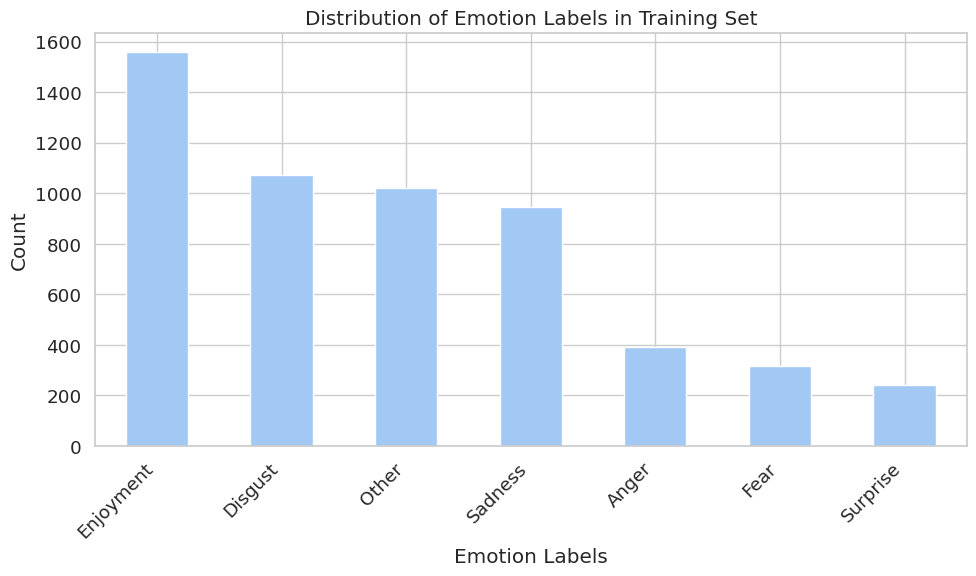

In [ ]:

emotion_counts = df['Emotion'].value_counts()
print(emotion_counts)

plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar')
plt.title('Distribution of Emotion Labels in Training Set')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

####__Lưu ý__:
Trong dataset này thì các các nhãn bị lệch nghiêm trọng các nhãn như Ẹnoyment Disgust Other Sadness đều có nhiều mẫu còn 3 nhãn còn lại thiếu mẫu nghiêm trọng. Điều này có thể ảnh hưởng lớn đến mô hình.

### __Xử lí dữ liệu__

Nếu đã từng làm việc với máy học thì ta biết rằng các mô hình không hoạt động trên dữ liệu văn bản thuần. Ta cần phải chế biến dữ liệu văn bản này thành một dạng nào đó thì các mô hình này mới có thể làm việc và học được. Mô hình BERT yêu cầu dữ liệu phải thỏa mãn các yêu cầu sau:
- Có các token đặc biệt để ngăn cách các câu và để thực hiện nhận dạng.
- Các chuỗi câu phải có cùng kích thước với nhau. Nếu dữ liệu dài hay ngắn hơn thì phải thực hiện đệm thêm (padding) hoặc bỏ bớt (truncating) đi ký tự để cho có cùng một kích thước.
- Phải có một mảng _attention_masks_ gồm các giá trị 1 và 0 để đánh dấu các token cần quan tâm và token bị bỏ qua.

Thư viện Transformers rất tiện lợi cung cấp cho chúng ta các Tokenizer đã được huấn luyện sẵn dùng để token hóa dữ liệu để trở thành dạng phù hợp cho các mô hình, bao gồm cả BERT. Hơn nữa, ta có thể sử dụng lớp hỗ trợ AutoTokenizer để thư viện chọn Tokenizer hợp lý nhất cho mô hình của mình. Ta sẽ nghiên cứu cách hoạt động của nó.

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 5548
    })
    validation: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 686
    })
    test: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 693
    })
})

Đây là cấu trúc của một đối tượng **DatasetDict** từ thư viện `datasets` của Hugging Face.
Cấu trúc này bao gồm 3 thành phần chính (thường gọi là các "split"):

* **train (Tập huấn luyện):** Gồm **5.548** dòng. Đây là dữ liệu dùng để "dạy" mô hình học cách nhận biết cảm xúc từ câu văn.
* **validation (Tập kiểm thử/xác thực):** Gồm **686** dòng. Dùng để đánh giá mô hình sau mỗi chu kỳ huấn luyện nhằm điều chỉnh các tham số và tránh hiện tượng học vẹt (overfitting).
* **test (Tập kiểm tra):** Gồm **693** dòng. Đây là dữ liệu hoàn toàn mới mà mô hình chưa từng thấy, dùng để đánh giá khách quan sức mạnh thực tế của mô hình sau khi đã huấn luyện xong.

Mỗi tập (split) đều có cấu trúc giống nhau về định dạng:

* **features (Đặc trưng):** Gồm 2 cột dữ liệu chính:
* `Sentence`: Chứa nội dung văn bản (đầu vào).
* `Emotion`: Chứa nhãn cảm xúc tương ứng (đầu ra/mục tiêu).


* **num_rows (Số lượng dòng):** Tổng số ví dụ có trong tập dữ liệu đó.


Cài & khởi tạo VnCoreNLP (RDRSegmenter)

In [ ]:
!pip install -q vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!apt-get -qq install openjdk-8-jdk-headless -y > /dev/null

In [ ]:
# 3. Tải bộ cài VnCoreNLP (file .zip)
!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip



--2026-01-15 12:30:39--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2026-01-15 12:30:39--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [             <=>    ] 160.84M  17.4MB/s    in 11s     

2026-01-15 12:30:51 (14.5 MB/s) - ‘master.zip’ saved [168648997]



In [ ]:
# 4. Giải nén file zip
!unzip -q master.zip

In [ ]:
from vncorenlp import VnCoreNLP

# 5. Khởi tạo VnCoreNLP với đường dẫn mới
# Trỏ vào /content/VnCoreNLP-master/VnCoreNLP-1.1.1.jar.. nếu dùng colab và
# /kaggle/working/VnCoreNLP-master/VnCoreNLP-1.1.1.jar nếu dùng kaggle

vncorenlp_path = "/content/VnCoreNLP-master/VnCoreNLP-1.1.1.jar"

# Khởi tạo (sử dụng annotator 'wseg' để tách từ giống như bạn)
rdr = VnCoreNLP(vncorenlp_path, annotators="wseg", max_heap_size='-Xmx2g')

print(" VnCoreNLP loaded successfully!")

# 6. Sử dụng để tách từ
text = "Phim này chán ngắt, phí cả tiền vé 😡 "

segmented_text = rdr.tokenize(text)
print(segmented_text)

 VnCoreNLP loaded successfully!
[['Phim', 'này', 'chán_ngắt', ',', 'phí', 'cả', 'tiền', 'vé', '😡']]


###__Hàm tách từ + batching + cache__

**Mục đích chính:**

>Mục đích của đoạn code là thực hiện tách từ tiếng Việt (word segmentation) một cách tối ưu về hiệu suất. Nó tập trung vào việc xử lý hàng loạt (batch) để tăng tốc độ và sử dụng cơ chế lưu bộ nhớ đệm (caching) để tránh lãng phí thời gian tính toán lại những dữ liệu đã từng xử lý trước đó.

**Quy trình thực hiện**

Quy trình được chia thành các bước logic sau:

* **Bước 1: Chuẩn bị nơi lưu trữ**

>Tự động tạo thư mục /content/seg_cache để chứa các file kết quả.

>Hàm _cache_path đảm bảo đường dẫn file (dấu / hoặc \) luôn đúng với hệ điều hành đang chạy.

* **Bước 2: Kiểm tra Cache (Trước khi xử lý)**

>Khi gọi hàm batch_segment, mã sẽ tạo ra một "tên file đại diện" bằng cách mã hóa (hashing MD5) nội dung văn bản đầu vào. Nếu nội dung không đổi, mã hash này sẽ giống hệt nhau.

>Hệ thống kiểm tra xem file này đã tồn tại trong thư mục cache chưa.

>Nếu có (Cache Hit): Mở file (pickle.load) và trả về kết quả ngay lập tức (rất nhanh).

Nếu không: Chuyển sang Bước 3.

* **Bước 3: Xử lý và Tách từ (Nếu chưa có Cache)**

>Làm sạch dữ liệu: Hàm segment_vi đảm bảo đầu vào luôn là chuỗi văn bản (xử lý lỗi nếu gặp None hoặc số).

>Chia nhỏ (Batching): Dữ liệu lớn được chia thành từng nhóm nhỏ (chunk) để gửi vào bộ tách từ rdr.tokenize. Việc này nhanh hơn nhiều so với việc xử lý từng câu lẻ tẻ.

>Định dạng: Kết quả trả về sẽ nối các từ đa âm bằng dấu gạch dưới _ và các từ cách nhau bằng khoảng trắng (Ví dụ: "Học_sinh học sinh_học").

**Bước 4: Lưu trữ kết quả**

>Sau khi tách từ xong, kết quả được đóng gói lại (pickle.dump) và ghi xuống ổ cứng. Việc này đảm bảo lần chạy sau sẽ rơi vào trường hợp "Có Cache" ở Bước 2.


In [ ]:

from typing import List, Optional
import hashlib
import pickle
import os

CACHE_DIR = "/content/seg_cache" # Tạo một thư mục để lưu các file kết quả.
os.makedirs(CACHE_DIR, exist_ok=True) # Tự động tạo thư mục này nếu nó chưa tồn tại.

def _cache_path(name: str) -> str:
# Quy định rõ đầu vào phải là một chuỗi văn bản (tên file) và đầu ra trả về cũng là một chuỗi văn bản (đường dẫn)
    return os.path.join(CACHE_DIR, name)
    # Tự động xử lý các dấu gạch chéo (/ hoặc \) sao cho đúng với hệ điều hành đang dùng (Windows, Linux hay MacOS)

def segment_vi(text: str) -> str:
    """Tách từ 1 câu: trả về chuỗi có các từ cách nhau bởi khoảng trắng, đa âm nối '_'."""
    if not isinstance(text, str):
        text = "" if text is None else str(text)
    # rdr.tokenize trả về List[List[str]] (mỗi sent 1 list token) Ví dụ: [["Học_sinh", "học", "sinh_học"]]. Ghép lại theo space.
    sents = rdr.tokenize(text)
    tokens = []
    for sent in sents:
        tokens.extend(sent)
    return " ".join(tokens)
    # Nối các từ trong danh sách tokens lại thành một chuỗi văn bản duy nhất, các từ cách nhau bởi một khoảng trắng
    # Ví dụ: "Học_sinh học sinh_học"

def batch_segment(texts: List[str], cache_name: Optional[str]=None, batch_size: int=256) -> List[str]:
    """Tách từ theo batch; có cache để lần sau không phải làm lại."""
    if cache_name is None:
        # Tạo tên cache ổn định theo hash nội dung (nhanh với số lượng vừa phải)
        m = hashlib.md5(("||".join(map(lambda x: x if isinstance(x, str) else str(x), texts))).encode("utf-8")).hexdigest()
        cache_name = f"seg_{m}.pkl"
        # Thuật toán md5 sẽ biến toàn bộ văn bản thành một chuỗi mã hóa ngắn duy nhất.
    path = _cache_path(cache_name)
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
            # Trước khi chạy máy tách từ, nó kiểm tra xem file kết quả đã nằm trong thư mục /content/seg_cache chưa.
            # Nếu có, nó chỉ việc (load file .pkl) và trả kết quả ngay lập tức.
    out = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i+batch_size]
        # rdr.tokenize có thể nhận list(str) và trả về list(list(list(str)))
        para_tok = rdr.tokenize(chunk)
        for sents in para_tok:
            tokens=[]
            for sent in sents:
                tokens.extend(sent)
            out.append(" ".join(tokens))
    with open(path, "wb") as f:
        pickle.dump(out, f)
        # Sau khi tính toán xong, nó dùng pickle để đóng gói kết quả lại và lưu xuống ổ cứng.
        # Lần chạy tiếp theo, nó sẽ rơi vào trường hợp (Cache Hit)
    return out

###__Tải Tokenizer và đưa vào bộ nhớ.__

In [ ]:


# 1. Từ điển Mapping Icon
icon_mapping = [
    ("😡", "giận"), ("😠", "giận"), ("🤬", "chửi"),
    ("😭", "khóc"), ("😢", "buồn"), ("☹️", "buồn"),
    ("😁", "cười"), ("😂", "cười"), ("🤣", "cười"),
    ("😱", "sợ"), ("😨", "sợ"),
    ("🥰", "yêu"), ("❤️", "yêu"),
    ("👍", "tốt"), ("🥹", "khóc")
]

In [ ]:
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset, DatasetDict
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from sklearn.metrics import f1_score
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

# === labels/setup ===
# Cập nhật nhãn dựa trên dữ liệu thực trong notebook
emotion_labels = [
    "Other", "Disgust", "Enjoyment", "Sadness", "Fear", "Surprise", "Anger"
]
NUM_LABELS = len(emotion_labels) # Should be 7

id2label = {i: l for i, l in enumerate(emotion_labels)}
label2id = {l: i for i, l in enumerate(emotion_labels)}
# Tạo từ điển chuyển đổi qua lại giữa con số và tên cảm xúc (Ví dụ: 0 <-> Other).


# --- CẤU HÌNH ---
MODEL_NAME = "vinai/phobert-base-v2"

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification"
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

# Tải cấu hình và bộ mã hóa của PhoBERT...

# A. Lấy danh sách icon cần thêm
new_icons = [pair[0] for pair in icon_mapping]

# B. Thêm icon vào từ điển của Tokenizer
tokenizer.add_tokens(new_icons)
model.resize_token_embeddings(len(tokenizer)) # Mở rộng bộ nhớ model
print(f"Đã thêm {len(new_icons)} icon vào Tokenizer.")

# C. Embedding Initialization
# Lấy tầng Embedding gốc
embeddings = model.roberta.embeddings.word_embeddings.weight


with torch.no_grad():
    for icon, word in icon_mapping:
        # Lấy ID của icon mới (Vừa thêm ở trên, vector đang rỗng/ngẫu nhiên)
        icon_id = tokenizer.convert_tokens_to_ids(icon) # Ví dụ: lấy ID của "😡"

        # Lấy ID của từ tiếng Việt (Đã train sẵn)
        word_ids = tokenizer.encode(word, add_special_tokens=False) # Ví dụ: Lấy ID của từ "giận"

        if len(word_ids) > 0:
            vietnamese_id = word_ids[0] # Lấy token đầu tiên

            # COPY: Gán vector từ "giận" sang cho "😡"
            embeddings[icon_id] = embeddings[vietnamese_id]
            # print(f"Đã copy năng lực từ '{word}' sang '{icon}'")

print(">>> Done!")


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Đã thêm 15 icon vào Tokenizer.
>>> Done!


**Quy trình:**

Bước 1: Tách từ và Lưu trữ (Segmentation & Caching):
>Thay vì tự sinh mã Hash, hàm batch_segment_v2 ở đây nhận thẳng một đường dẫn file (ví dụ: train_texts_seg.pkl).Nó kiểm tra file này có chưa $\rightarrow$ Nếu chưa thì chạy hàm vi_segment_one để tách từ $\rightarrow$ Lưu lại.

Bước 2: Xử lý dữ liệu thô (Extraction & Encoding):
>Lấy cột Sentence (câu văn) và Emotion (nhãn) từ biến dataset.Dòng [label2id[emotion] ...] thực hiện việc tra từ điển để biến chữ thành số.

Bước 3: Đóng gói (Dataset Construction):
>Dùng Dataset.from_dict để ghép danh sách câu (đã tách từ) và danh sách nhãn (số) thành một bảng dữ liệu thống nhất cho từng tập (train, val, test).

Bước 4: Tokenize & MapTokenize:
>Hàm tokenize_fn gọi tokenizer để cắt câu thành các token số, cắt bớt nếu dài quá 320 từ (truncation=True).Map: Lệnh .map(..., batched=True) áp dụng hàm tokenize lên toàn bộ dữ liệu cùng lúc.

Remove columns: Nó xóa cột "text" gốc đi, chỉ giữ lại các vector số (input_ids, attention_mask) để đưa vào mô hình cho nhẹ.


In [ ]:
import os, pickle
from typing import List
from datasets import Dataset, DatasetDict

CACHE_DIR = "./seg_cache"
# Kiểm tra xem thư mục "./seg_cache" đã có chưa.
os.makedirs(CACHE_DIR, exist_ok=True)

def vi_segment_one(text: str) -> str:
    """Hàm này nhận vào 1 câu văn bản thô và trả về câu đã tách từ."""
    # Giả định biến 'rdr' (RDRSegmenter) đã được khởi tạo ở code trước đó.
    # rdr.tokenize trả về cấu trúc lồng nhau: Ví dụ [['Học_sinh', 'đang', 'học']]
    sents = rdr.tokenize(text)
    tokens = []
    # Duyệt qua từng danh sách con để làm phẳng (flatten) cấu trúc dữ liệu
    for sent in sents:
        tokens.extend(sent) # Gom tất cả từ vào 1 list duy nhất

    # Nối lại thành chuỗi, các từ cách nhau bởi khoảng trắng.
    # Ví dụ output: "Học_sinh đang học"
    return " ".join(tokens)


def batch_segment_v2(texts: List[str], cache_path: str) -> List[str]:
    """
    Xử lý tách từ cho cả danh sách.
    Cơ chế: Kiểm tra file .pkl trước -> Nếu có thì load -> Nếu không thì mới tính toán.
    """
    # [Cơ chế Cache Hit]: Kiểm tra xem file kết quả (cache_path) đã nằm trên ổ cứng chưa
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            # Nếu có, đọc file nhị phân này lên RAM và trả về ngay lập tức.
            # pickle.load cực nhanh so với việc chạy vòng lặp tách từ.
            return pickle.load(f)

    # [Cơ chế Cache Miss]: Nếu chưa có file cache, phải xử lý thủ công.
    # Dùng List Comprehension để chạy hàm vi_segment_one cho từng câu trong danh sách texts.
    out = [vi_segment_one(t) for t in texts]

    # Sau khi tính xong, lưu (dump) kết quả xuống ổ cứng ngay để lần sau không phải tính lại.
    with open(cache_path, "wb") as f:
        pickle.dump(out, f)

    return out # Trả về danh sách đã tách từ

train_texts = dataset['train']['Sentence']
val_texts = dataset['validation']['Sentence']
test_texts = dataset['test']['Sentence']


train_labels_ids = [label2id[emotion] for emotion in dataset['train']['Emotion']]
val_labels_ids = [label2id[emotion] for emotion in dataset['validation']['Emotion']]
test_labels_ids = [label2id[emotion] for emotion in dataset['test']['Emotion']]


train_texts_seg = batch_segment_v2(train_texts, os.path.join(CACHE_DIR, "train_texts_seg.pkl"))
val_texts_seg   = batch_segment_v2(val_texts,   os.path.join(CACHE_DIR, "val_texts_seg.pkl"))
test_texts_seg  = batch_segment_v2(test_texts,  os.path.join(CACHE_DIR, "test_texts_seg.pkl"))



train_ds = Dataset.from_dict({"text": train_texts_seg, "labels": train_labels_ids})
val_ds   = Dataset.from_dict({"text": val_texts_seg,   "labels": val_labels_ids})
test_ds  = Dataset.from_dict({"text": test_texts_seg,  "labels": test_labels_ids})


def tokenize_fn(batch):
    """Hàm phụ trợ để biến văn bản thành vector số (input_ids)"""
    # tokenizer: Biến văn bản thành các con số ID trong từ điển của model
    # truncation=True: Nếu câu dài hơn max_length, nó sẽ bị cắt bớt phần đuôi.
    return tokenizer(batch["text"], truncation=True, max_length=320)

ds = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds}).map(
    tokenize_fn, batched=True, remove_columns=["text"]
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]

### __Quy trình kiểm tra lại khả năng của Tokenizer__

In [ ]:
print("\n--- Kiểm tra khả năng của Tokenizer ---")

sample_text_1 = "Phim này chán ngắt, phí cả tiền vé 😡"
sample_text_2 = "mới lụm được 50k rồi, vui quá đi ❤️"
sample_text_3 = "Tôi rất buồn 😭 vì bài kiểm tra bị điểm thấp. "
sample_text_4 = "Cái này tốt 👍 nha."
sample_text_5 = "Tôi là sinh viên khoa Toán"


print(f"\nOriginal text (with emoji): {sample_text_1}")

# Tokenize without segmentation (tokenizer will split based on its vocabulary)
encoded_no_seg = tokenizer(sample_text_1, return_tensors='pt')
print("Tokenized (no segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_no_seg['input_ids'][0]))
print("Input IDs:", encoded_no_seg['input_ids'][0].tolist())

# Segment the text first
segmented_text_1 = vi_segment_one(sample_text_1)
segmented_text_2 = vi_segment_one(sample_text_2)
segmented_text_3 = vi_segment_one(sample_text_3)
segmented_text_4 = vi_segment_one(sample_text_4)
segmented_text_5 = vi_segment_one(sample_text_5)

print(f"\nSegmented text: {segmented_text_1}")

# Tokenize with segmentation
encoded_seg = tokenizer(segmented_text_1, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg['input_ids'][0]))
print("Input IDs:", encoded_seg['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_2}")
encoded_seg_2 = tokenizer(segmented_text_2, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_2['input_ids'][0]))
print("Input IDs:", encoded_seg_2['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_3}")
encoded_seg_3 = tokenizer(segmented_text_3, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_3['input_ids'][0]))
print("Input IDs:", encoded_seg_3['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_4}")
encoded_seg_4 = tokenizer(segmented_text_4, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_4['input_ids'][0]))
print("Input IDs:", encoded_seg_4['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_5}")
encoded_seg_5 = tokenizer(segmented_text_5, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_5['input_ids'][0]))
print("Input IDs:", encoded_seg_5['input_ids'][0].tolist())


--- Kiểm tra khả năng của Tokenizer ---

Original text (with emoji): Phim này chán ngắt, phí cả tiền vé 😡
Tokenized (no segmentation):
['<s>', 'Phim', 'này', 'chán', 'ng@@', 'ắ@@', 't@@', ',', 'phí', 'cả', 'tiền', 'vé', '😡', '</s>']
Input IDs: [0, 3880, 23, 5015, 1701, 13572, 1187, 4, 848, 94, 123, 826, 64001, 2]

Segmented text: Phim này chán_ngắt , phí cả tiền vé 😡
Tokenized (with segmentation):
['<s>', 'Phim', 'này', 'chán_@@', 'ngắt', ',', 'phí', 'cả', 'tiền', 'vé', '😡', '</s>']
Input IDs: [0, 3880, 23, 40743, 9515, 4, 848, 94, 123, 826, 64001, 2]

Segmented text: mới lụm được 50k rồi , vui quá đi ❤️
Tokenized (with segmentation):
['<s>', 'mới', 'l@@', 'ụm', 'được', '50@@', 'k', 'rồi', ',', 'vui', 'quá', 'đi', '❤️', '</s>']
Input IDs: [0, 60, 1494, 30213, 11, 6825, 1947, 182, 4, 911, 204, 57, 64013, 2]

Segmented text: Tôi rất buồn 😭 vì bài kiểm_tra bị điểm thấp .
Tokenized (with segmentation):
['<s>', 'Tôi', 'rất', 'buồn', '😭', 'vì', 'bài', 'kiểm_tra', 'bị', 'điểm', 'thấp', '.', 

###__Huấn luyện (Training) và đánh giá (Evaluation)__

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import EarlyStoppingCallback

# Hàm này được gọi sau mỗi epoch đánh giá để xem model học tốt đến đâu.
def compute_metrics(eval_pred):
    """
    eval_pred chứa 2 phần:
    - logits: Điểm số thô model dự đoán (chưa qua hàm softmax).
    - labels: Đáp án đúng thực tế.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Tính độ chính xác tổng thể (đúng bao nhiêu % trên tổng số).
    acc = accuracy_score(labels, predictions)

    # F1-Macro: Sử dụng khi dữ liệu mất cân bằng.
    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)

    # F1-Weighted: Tính trung bình có trọng số (lớp nhiều mẫu sẽ chiếm tỉ trọng lớn hơn trong điểm số).
    f1_weighted = f1_score(labels, predictions, average="weighted", zero_division=0)

    # Trả về từ điển kết quả để Trainer log ra màn hình.
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

args = TrainingArguments(
    output_dir="./phobert-slc-vncorenlp", # Nơi lưu model

    # Batch size: Số lượng câu đưa vào model cùng lúc.
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    learning_rate=2e-5,
    weight_decay=0.01,              # Một kỹ thuật chống Overfitting.
    num_train_epochs=10,            # Số lần học lặp lại toàn bộ dữ liệu.

    label_smoothing_factor = 0.08,  # Làm mềm nhãn: Thay vì bắt model tự tin tuyệt đối (1.0), chỉ cần (0.92). Giúp chống Overfitting.
    warmup_ratio=0.06,              # Tăng dần LR lúc đầu để model làm quen.

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Tiêu chí chọn model tốt nhất (Do dữ liệu lệch nên chọn F1 thay vì Accuracy).
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    # Cơ chế dừng sớm: Nếu sau 3 lần kiểm tra (patience=3) mà điểm 'f1_macro' không tăng
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

## __3. Phân loại cảm xúc và chủ đề__

### __Chỉ số đánh giá__

### __Huấn luyện mô hình__

Ta sử dụng Trainer để kết nối mọi thứ đề cập ở trên để tạo bộ huấn luyện.

In [ ]:

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.501800,1.301031,0.609329,0.424075,0.562799
2,1.129900,1.209455,0.634111,0.553786,0.620199
3,0.993600,1.164433,0.655977,0.576331,0.645995
4,0.820800,1.215787,0.631195,0.572587,0.624931
5,0.673900,1.319752,0.628280,0.554422,0.614689
6,0.600300,1.367949,0.651603,0.598161,0.646624
7,0.548500,1.410736,0.651603,0.602179,0.650374
8,0.507500,1.485556,0.641399,0.586620,0.641817
9,0.482400,1.539994,0.637026,0.576632,0.634680
10,0.473500,1.541420,0.637026,0.579334,0.636479


TrainOutput(global_step=3470, training_loss=0.7974925849210975, metrics={'train_runtime': 772.6133, 'train_samples_per_second': 71.808, 'train_steps_per_second': 4.491, 'total_flos': 1118233128299400.0, 'train_loss': 0.7974925849210975, 'epoch': 10.0})

####__Phân tích__:
Chúng ta có thể phân tích được nhiều thông tin quan trọng về hiệu suất và tình trạng của mô hình.

* **Training Loss:** Giảm đều đặn và rất sâu (từ **1.50** xuống **0.47**). Điều này chứng tỏ mô hình học dữ liệu huấn luyện rất tốt.
* **Validation Loss:** Chỉ giảm đến Epoch 3 (**1.16**), sau đó **tăng ngược trở lại** liên tục và kết thúc ở mức **1.54**.

Dựa vào bảng, **Epoch 3** hoặc **Epoch 7** là những thời điểm mô hình tốt nhất:

* **Tại Epoch 3:** Validation Loss thấp nhất (**1.16**). Đây thường là điểm dừng lý tưởng để mô hình có khả năng tổng quát hóa tốt nhất.
* **Tại Epoch 7:** Các chỉ số như **Accuracy (0.65)** và **F1 Macro (0.60)** đạt mức cao nhất.

* **Accuracy (~65%):** Mô hình đoán đúng khoảng 65% tổng số mẫu. Với bài toán 7 nhãn cảm xúc, con số này ở mức khá (có thể vẫn còn nhiều không gian để cải thiện).
* **F1 Macro vs F1 Weighted:** * **F1 Macro (khoảng 0.58 - 0.60):** Chỉ số này thấp hơn Accuracy đáng kể, cho thấy bộ dữ liệu bị **mất cân bằng (imbalance)**. Có một số nhãn cảm xúc mô hình học rất kém, trong khi một số khác lại học rất tốt. Lí do bộ dữ liệu ban đầu đã bị mất cân bằng.
* **F1 Weighted:** Cao hơn Macro, củng cố thêm giả thuyết về việc các nhãn chiếm đa số trong dữ liệu đang "kéo" điểm số lên.

* **Thời gian huấn luyện:** Tổng cộng khoảng **7 phút 46 giây** cho 10 Epoch (tốc độ ~118 mẫu/giây).
* **Tính toán:** Chỉ số `total_flos` cực lớn cho thấy mô hình Transformer đã thực hiện một khối lượng tính toán khổng lồ để xử lý các từ ngữ.


#### __Đánh giá__

Thực hiện đánh giá mô hình.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
from scipy.special import softmax


def evaluate_on_test(trainer, test_ds, label_names=None, plot=True):
    """
    Evaluate SINGLE-LABEL classifier with metrics + plots.
    """
    # === Predict ===
    out = trainer.predict(test_ds)
    logits = out.predictions
    y_pred = np.argmax(logits, axis=-1)
    y_true = np.array(test_ds["labels"])

    # === Metrics ===
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print("Test results (Single-Label):")
    print(f"- Accuracy           : {acc:.4f}")
    print(f"- F1 Macro           : {f1_macro:.4f}")
    print(f"- F1 Weighted        : {f1_weighted:.4f}")
    print(f"- Precision Macro    : {precision_macro:.4f}")
    print(f"- Recall Macro       : {recall_macro:.4f}")

    # === Classification report ===
    if label_names is not None:
        print("\nClassification Report:")
        print(classification_report(
            y_true, y_pred,
            target_names=label_names,
            zero_division=0
        ))

    # === Plots ===
    if plot:
        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

        # 2. Confidence distribution (softmax)
        probs = softmax(logits, axis=-1)
        max_conf = np.max(probs, axis=-1)

        plt.figure()
        plt.hist(max_conf, bins=30)
        plt.title("Prediction Confidence Distribution")
        plt.xlabel("Max softmax probability")
        plt.ylabel("Number of samples")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro
    }


Test results (Single-Label):
- Accuracy           : 0.6811
- F1 Macro           : 0.6496
- F1 Weighted        : 0.6806
- Precision Macro    : 0.6608
- Recall Macro       : 0.6431

Classification Report:
              precision    recall  f1-score   support

       Other       0.56      0.59      0.58       129
     Disgust       0.65      0.69      0.67       132
   Enjoyment       0.78      0.76      0.77       193
     Sadness       0.76      0.76      0.76       116
        Fear       0.65      0.72      0.68        46
    Surprise       0.69      0.54      0.61        37
       Anger       0.55      0.45      0.49        40

    accuracy                           0.68       693
   macro avg       0.66      0.64      0.65       693
weighted avg       0.68      0.68      0.68       693



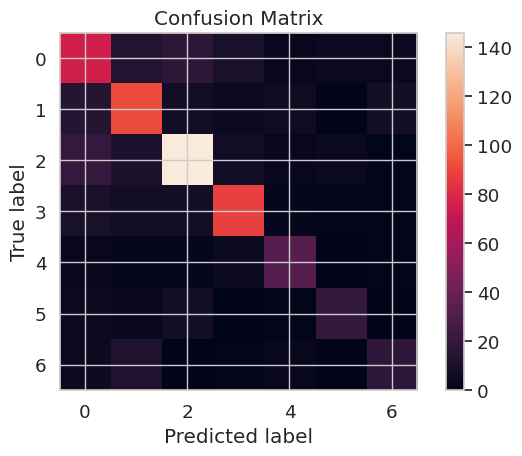

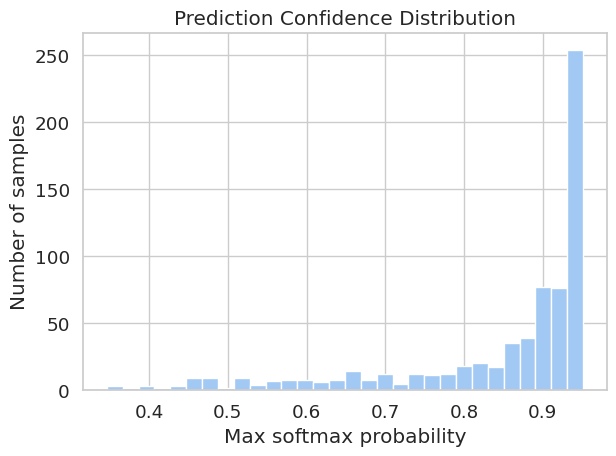

In [ ]:
metrics = evaluate_on_test(
    trainer,
    ds["test"],
    label_names=emotion_labels,
    plot=True
)


###__Phân tích kết quả và so sánh__

**Phân tích:**
1. Classification Report

* Hai cảm xúc mô hình nhận diện tốt nhất (F1 lần lượt là `Enjoyment`với **0.77** và `Sadness` **0.76**).
* **Nhãn "Gây khó khăn" (Anger & Other):** * **Anger (Giận dữ):** Có F1-score thấp nhất (**0.49**). Nếu nhìn sang Recall (**0.45**), nghĩa là hơn một nửa số câu giận dữ đã bị đoán sai sang nhãn khác.


* Các nhãn như *Fear, Surprise, Anger* có số lượng mẫu rất ít (chỉ khoảng 40 mẫu), so với *Enjoyment* (193 mẫu). Đây là nguyên nhân chính khiến mô hình không đủ dữ liệu để học tốt các nhãn này.

2. Confusion Matrix

* **Nhãn 0 (Other) và Nhãn 1 (Disgust):** Có một sự giao thoa nhẹ. Mô hình đôi khi không phân biệt được sự khó chịu rõ rệt và các cảm xúc trung tính/khác.
* **Nhãn 6 (Anger):** Các ô màu tối ở hàng cuối cho thấy nó bị tán xạ sang nhiều nhãn khác nhau chứ không tập trung vào một nhãn sai cố định nào. Điều này cho thấy các câu "Giận dữ" trong tập dữ liệu có thể chứa từ ngữ quá đa dạng hoặc bị chồng lấn ý nghĩa.

3. Prediction Confidence Distribution

* **Cột cao nhất ở mức > 0.9:** Đa số các mẫu đều được dự đoán với xác suất trên 90%.

4. Tổng kết sức mạnh thực tế

* **Accuracy (68.11%):** Trong môi trường thực tế, cứ 10 câu khách hàng nói, mô hình sẽ đoán đúng khoảng 7 câu.
* **Macro Avg F1 (0.65):** Con số này thực tế hơn Accuracy. Nó cho thấy khả năng phân loại tổng thể của hệ thống ở mức **Khá**

Tổng kết:

>Mô hình PhoBERT rất mạnh trong việc nhận diện các cảm xúc tích cực (Enjoyment) và nỗi buồn (Sadness) trong tiếng Việt.

**So sánh với kết quả từ bài báo cáo : NGHIÊN CỨU NÂNG CAO NHẬN DẠNG CẢM XÚC TIẾNG VIỆT: PHƯƠNG PHÁP DỰA TRÊN PHOBERT PHỤC VỤ TƯƠNG TÁC HIỆU QUẢ trên bộ dataset UIT-VSMEC.** __[Đường link](https://jst.tnu.edu.vn/jst/article/download/12889/pdf)__.

Bảng so sánh hiệu năng mô hình trên tập UIT-VSMEC
| Models | Accuracy | Precision (Macro) | Recall (Macro) | F1-score (Macro) |
| :--- | :--- | :--- | :--- | :--- |
| **Ours (PhoBERT v2 + Emoji)** | **68.11%** | **66.08%** | **64.31%** | **64.96%** |
| PhoBERT-base-v2 (Baseline) | 63.31% | 63.31% | 63.08% | 63.53% |
| SVM | 58.59% | 58.62% | 52.76% | 54.65% |
| CNN-LSTM | 52.81% | 59.55% | 41.11% | 41.33% |
| BiLSTM | 50.94% | 53.84% | 45.43% | 47.65% |
| RNN | 27.85% | 3.98% | 14.29% | 6.22% |

> *Nhận xét:*

> *Kết quả thực nghiệm của nhóm đều cao hơn so với kết quả công bố trong bài báo tham khảo ở tất cả các chỉ số. Đặc biệt là chỉ số Accuracy tăng mạnh gần 5% (từ 63.31% lên 68.11%).*

> *Chỉ số F1-Macro (trung bình điều hòa giữa Precision và Recall) của nhóm cao hơn (64.96% so với 63.53%). Điều này chứng tỏ mô hình của nhóm xử lý các lớp dữ liệu thiểu số (các cảm xúc ít xuất hiện) tốt hơn so với baseline của bài báo.*


### __Dự đoán trên văn bản bất kỳ__

In [ ]:
from typing import List, Optional, Union
import numpy as np
import torch
import pandas as pd
from scipy.special import softmax # Dùng softmax cho single-label

@torch.no_grad()
def predict_emotions(
    texts: Union[str, List[str]],
    model,
    tokenizer,
    emotion_labels: List[str],
    use_segmentation: bool = True,
    max_length: int = 256,
    batch_size: int = 32,
    return_scores: bool = True,
    top_k: Optional[int] = None,
):
    # 1. Chuẩn hóa input
    single = False
    if isinstance(texts, str):
        texts = [texts]
        single = True
    # 2. Tách từ (nếu cần)
    if use_segmentation:
        # Đảm bảo có hàm vi_segment_one
        seg_texts = [vi_segment_one(t) for t in texts]
    else:
        seg_texts = list(texts)
    device = next(model.parameters()).device
    results = []
    # 3. Dự đoán theo batch
    for i in range(0, len(seg_texts), batch_size):
        batch_texts = seg_texts[i:i+batch_size]
        # Tokenize
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        # Model forward
        outputs = model(**enc)
        logits = outputs.logits.detach().cpu().numpy() # [Batch_size, Num_labels]
        probs = softmax(logits, axis=1)
        # 4. Xử lý kết quả từng mẫu
        for j, prob in enumerate(probs):
            # Lấy nhãn tốt nhất (Argmax)
            pred_id = np.argmax(prob)
            pred_label = emotion_labels[pred_id]
            pred_score = prob[pred_id]
            # Top-k (nếu cần xem các phương án dự phòng)
            topk_list = None
            if top_k is not None:
                # Sắp xếp giảm dần
                top_indices = np.argsort(-prob)[:top_k]
                topk_list = [(emotion_labels[idx], float(prob[idx])) for idx in top_indices]
            # Bảng điểm chi tiết
            score_df = None
            if return_scores:
                score_df = pd.DataFrame({
                    "label": emotion_labels,
                    "score": prob.astype(float)
                }).sort_values("score", ascending=False).reset_index(drop=True)
            results.append({
                "text": texts[i + j],
                "pred_label": pred_label,
                "confidence": float(pred_score),
                "top_k": topk_list,
                "scores": score_df
            })
    return results[0] if single else results

In [ ]:
texts = [
    "Giờ vẫn ôm món nợ vài trăm nữa thím ạ, nhiều lúc nghĩ nhục nhã lắm nhưng vẫn cố làm để trả dần từng món một",
    "Phim này chán ngắt, phí cả tiền vé 😡 ",
    "😡",
    "đùa vui đấy 😁",
    "đùa vui đấy 😡 ,",
    "trả tiền mau 😡",
    "trả tiền mau ",
    "cảm ơn nha",
    "hôm nay tao đi học bị nổ lốp xe mày ạ, xui quá ",
    "Cảm giác căng thẳng hôm nay không giống những ngày bình thường. Mình cứ nghĩ là mọi thứ sẽ ổn, rằng tình cảm giữa mình và V sẽ ngày càng tốt đẹp, nhưng sao hôm nay, khi mọi thứ vỡ vụn, mình lại cảm thấy như mình vừa bị tẩy chay, bị lợi dụng mà không hề hay biết.",
    "mày tự lập thì kệ thằng cụ nhà mày chứ, mỗi cây mỗi hoa, mỗi nhà mỗi cảnh, thằng thớt kêu than cuộc đời nó có đ gì sai. theo kinh nghiệm của tao, loại hay lên gân đạo lý là loại cóc nhái chó chết loser mạt hạng thôi",
    "bài này ghê thật 👍",
    "bài này ghê thật 😱"
  ]


preds = predict_emotions(texts, model, tokenizer, emotion_labels, top_k=3)

for p in preds:
    print(f"Text: {p['text']}")
    print(f"Dự đoán: {p['pred_label']} ({p['confidence']:.2%})")
    print(f"Top 3 khả năng: {p['top_k']}")
    print("-" * 30)




Text: Giờ vẫn ôm món nợ vài trăm nữa thím ạ, nhiều lúc nghĩ nhục nhã lắm nhưng vẫn cố làm để trả dần từng món một
Dự đoán: Sadness (92.42%)
Top 3 khả năng: [('Sadness', 0.9241737723350525), ('Fear', 0.02724451571702957), ('Enjoyment', 0.014481822960078716)]
------------------------------
Text: Phim này chán ngắt, phí cả tiền vé 😡 
Dự đoán: Disgust (89.45%)
Top 3 khả năng: [('Disgust', 0.8945409655570984), ('Sadness', 0.03808484971523285), ('Anger', 0.02014785446226597)]
------------------------------
Text: 😡
Dự đoán: Disgust (46.97%)
Top 3 khả năng: [('Disgust', 0.4697211980819702), ('Anger', 0.4153379201889038), ('Other', 0.03129314258694649)]
------------------------------
Text: đùa vui đấy 😁
Dự đoán: Enjoyment (93.76%)
Top 3 khả năng: [('Enjoyment', 0.9376128315925598), ('Other', 0.014043577015399933), ('Surprise', 0.012129989452660084)]
------------------------------
Text: đùa vui đấy 😡 ,
Dự đoán: Enjoyment (67.20%)
Top 3 khả năng: [('Enjoyment', 0.6720386743545532), ('Disgust', 0.


Trong trường hợp này (ví dụ trong slide):

1.  **`"bài này ghê thật 👍"`**: Emoji `👍` (like/good) đã được ánh xạ (copy embedding) từ từ `"tốt"`. Khi mô hình xử lý câu này, dù từ "ghê thật" có thể mang sắc thái tiêu cực hoặc bất ngờ, sự hiện diện của `👍` (mang ngữ nghĩa của "tốt") đã tác động mạnh mẽ đến dự đoán tổng thể của mô hình. Trong kết quả dự đoán, mô hình có xu hướng nhận diện cảm xúc là `Surprise` (bất ngờ tích cực) hoặc `Enjoyment`, cho thấy nó coi đây là một biểu hiện của sự ngạc nhiên hài lòng hoặc khen ngợi.

2.  **`"bài này ghê thật 😱"`**: Ngược lại, emoji `😱` (scream/fear) đã được ánh xạ từ từ `"sợ"`. Khi mô hình thấy `😱`, nó ngay lập tức liên kết với cảm xúc `Fear` (sợ hãi). Do đó, mặc dù phần văn bản "bài này ghê thật" giống hệt, emoji `😱` đã "kéo" dự đoán của mô hình về nhãn `Fear` với xác suất rất cao.

Điều này minh họa rõ ràng cách mà việc tích hợp emoji và gán ngữ nghĩa cho chúng thông qua kỹ thuật Copy Embedding Weights giúp mô hình nhạy bén hơn với sắc thái cảm xúc được truyền tải qua các biểu tượng hình ảnh, đặc biệt trong các ngữ cảnh ngôn ngữ mạng xã hội, nơi emoji đóng vai trò quan trọng trong việc thể hiện cảm xúc.

### __Thử nghiệm trên gradio__

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

def gradio_wrapper(text):
    if not text.strip():
        return None

    # Biến 'model', 'tokenizer', 'emotion_labels' lấy từ context notebook
    result = predict_emotions(
        texts=text,
        model=model,
        tokenizer=tokenizer,
        emotion_labels=emotion_labels,
        use_segmentation=True,
        return_scores=True
    )

    # Chuyển đổi DataFrame 'scores' thành dictionary cho Gradio Label
    # result['scores'] là DataFrame có cột 'label' và 'score'
    df_scores = result['scores']
    output_dict = dict(zip(df_scores['label'], df_scores['score']))

    return output_dict

# Tạo giao diện
if 'model' in globals():
    demo = gr.Interface(
        fn=gradio_wrapper,
        inputs=gr.Textbox(lines=2, placeholder="Nhập văn bản tiếng Việt..."),
        outputs=gr.Label(num_top_classes=3, label="Kết quả dự đoán"),
        title="Dự đoán Cảm Xúc (Custom Function)",
        description="Demo sử dụng hàm predict_emotions tùy chỉnh.",
        examples=[
            ["Mình rất thích món quà này!"],
            ["Hôm nay buồn quá, chẳng muốn làm gì."],
            ["Thật là một sự thất vọng tràn trề."]
        ])
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c58304c480726047b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### __Tổng kết và hướng cải tiến__:
> Kết quả thực nghiệm cho thấy mô hình PhoBERT v2 đã được tinh
chỉnh thành công, đạt hiệu suất phân loại tổng thể ở mức khả quan
với điểm Macro F1 xấp xỉ 0.65 ( cao hơn mô hình tham chiếu trên cùng dataset)

> Tuy nhiên, mô hình vẫn còn bị hạn chế bởi các vấn đề chưa được giải quyết
triệt để.
Đầu tiên là tình trạng mất cân bằng dữ liệu, đòi hỏi việc bổ sung
thêm mẫu cho các nhãn hiếm gặp như Anger và Fear. Thứ hai, các biến thể ngôn ngữ
mạng (teencode/slang) như ”khum”, ”j z tr”... vẫn gây nhiễu đáng kể
cho bộ tách từ chuẩn do chưa có cơ chế chuẩn hóa hiệu quả.





